# 05 - Feature Engineering

Day 2, step 5. Turning cleaned columns into model-ready features.

The rule from the build notes: **every engineered feature needs a stated
statistical or business reason.** Anything that merely "seemed interesting" is noise
the model has to learn to ignore, and with only 1,470 rows there is no budget for
that.

The implementation lives in `app/ml/features.py` and is embedded in the sklearn
pipeline as a step, so training and serving cannot drift apart.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from app.ml.features import (
    ENGINEERED_COLUMNS,
    EXCLUDED_COLUMNS,
    build_preprocessor,
    check_leakage,
    engineer_features,
    split_column_types,
)
from app.utils.config import PROCESSED_FILES

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df = pd.read_csv(PROCESSED_FILES["attrition"])
y = df["AttritionFlag"].astype(int)
print("input:", df.shape, "| positive rate:", round(y.mean(), 4))

input: (1470, 33) | positive rate: 0.1612


## What is deliberately excluded

In [2]:
print("Never used as features:", EXCLUDED_COLUMNS)

Never used as features: ['EmployeeID', 'Attrition', 'AttritionFlag']


`EmployeeID` matters most here. It is an arbitrary identifier, but a tree model will
happily split on it and carve out "high risk" ID ranges that mean nothing at all -
the model would score well in cross-validation and fail completely on new employees
whose IDs fall outside the training range.

## The engineered features

In [3]:
X = engineer_features(df)
print(f"columns: {df.shape[1]} -> {X.shape[1]}")
print(f"engineered: {ENGINEERED_COLUMNS}")
X[ENGINEERED_COLUMNS].describe().T.round(3)

columns: 33 -> 37
engineered: ['IncomePerYearAtCompany', 'TenureRatio', 'PromotionStagnation', 'AvgYearsPerCompany', 'IncomePerJobLevel', 'SatisfactionIndex', 'ManagerStability']


,count,mean,std,min,25%,50%,75%,max
IncomePerYearAtCompany,1470.0,1169.636,1353.979,101.571,517.634,793.121,1217.469,18061.000
TenureRatio,1470.0,0.582,0.284,0.000,0.368,0.636,0.833,0.976
PromotionStagnation,1470.0,0.392,0.632,0.000,0.000,0.200,0.667,7.000
AvgYearsPerCompany,1470.0,4.193,4.036,0.000,1.600,3.000,5.000,38.000
IncomePerJobLevel,1470.0,2973.801,770.641,1009.000,2394.125,2856.500,3478.833,4999.000
SatisfactionIndex,1470.0,2.723,0.504,1.250,2.500,2.750,3.000,4.000
ManagerStability,1470.0,0.466,0.277,0.000,0.286,0.500,0.667,0.895


| Feature | Reason it exists |
|---|---|
| `IncomePerYearAtCompany` | pay relative to tenure - long service on low pay is a classic flight risk that raw income cannot express |
| `TenureRatio` | share of the whole career spent here; separates movers from the invested |
| `PromotionStagnation` | time since promotion *relative to time in role* - being "due" is what matters, not the raw year count |
| `AvgYearsPerCompany` | average stint length - a direct behavioural measure of job-hopping |
| `IncomePerJobLevel` | pay fairness within a grade; under-payment relative to peers drives exits |
| `SatisfactionIndex` | one stable signal from four correlated Likert items |
| `ManagerStability` | a recent manager change is a well-documented attrition trigger |

## Do they actually separate leavers from stayers?

A feature with a reason still has to earn its place empirically.

In [4]:
comparison = pd.DataFrame({
    "stayed": X[y == 0][ENGINEERED_COLUMNS].mean(),
    "left": X[y == 1][ENGINEERED_COLUMNS].mean(),
})
comparison["difference_%"] = ((comparison["left"] - comparison["stayed"])
                              / comparison["stayed"].abs() * 100).round(1)
comparison.round(3)

,stayed,left,difference_%
IncomePerYearAtCompany,1171.419,1160.359,-0.9
TenureRatio,0.593,0.522,-12.0
PromotionStagnation,0.390,0.399,2.4
AvgYearsPerCompany,4.460,2.809,-37.0
IncomePerJobLevel,3012.292,2773.550,-7.9
SatisfactionIndex,2.764,2.513,-9.1
ManagerStability,0.484,0.369,-23.8


C:\Users\Devyansh Aggarwal\AppData\Local\Temp\ipykernel_26856\538482625.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["stayed", "left"], showfliers=False)
C:\Users\Devyansh Aggarwal\AppData\Local\Temp\ipykernel_26856\538482625.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["stayed", "left"], showfliers=False)
C:\Users\Devyansh Aggarwal\AppData\Local\Temp\ipykernel_26856\538482625.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["stayed", "left"], showfliers=False)
C:\Users\Devyansh Aggarwal\AppData\Local\Temp\ipykernel_26856\53848

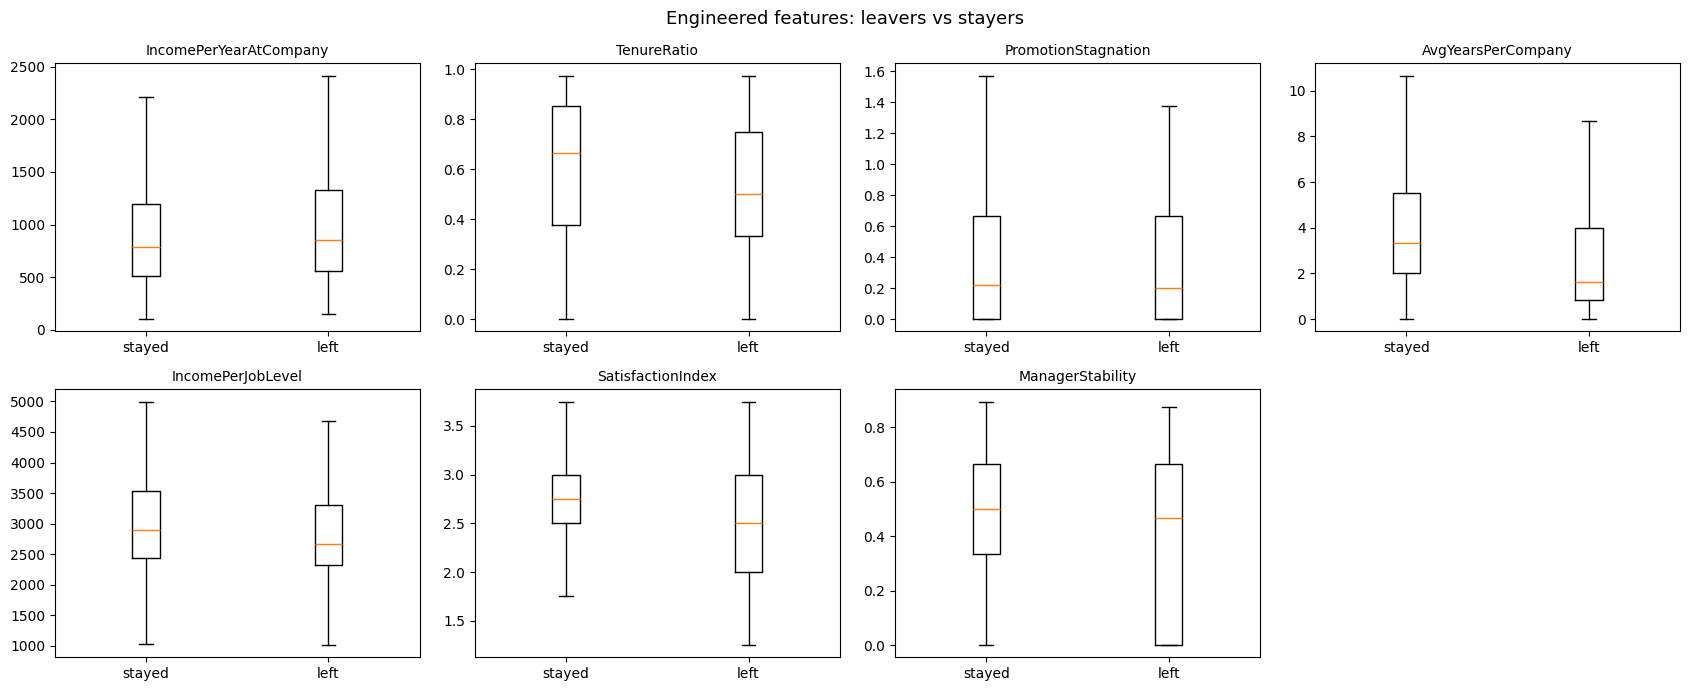

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for ax, col in zip(axes.ravel(), ENGINEERED_COLUMNS):
    data = [X.loc[y == 0, col].dropna(), X.loc[y == 1, col].dropna()]
    ax.boxplot(data, labels=["stayed", "left"], showfliers=False)
    ax.set_title(col, fontsize=10)
axes.ravel()[-1].axis("off")
fig.suptitle("Engineered features: leavers vs stayers", fontsize=13)
fig.tight_layout()
plt.show()

`IncomePerYearAtCompany` separates most sharply - leavers earn noticeably less per
year of service. `TenureRatio` and `ManagerStability` are lower for leavers, matching
the expectation that people who have invested less time here are likelier to go.

## Leakage check

Nothing may predict the target nearly perfectly. A feature that does is almost always
a proxy for the answer that would not exist at prediction time.

In [6]:
leakage = check_leakage(X, y)
print("Any suspicious features?", bool(leakage["suspicious"].any()))
leakage.head(15)

Any suspicious features? False


,feature,metric,value,suspicious
0,SatisfactionIndex,abs_correlation,0.1831,False
1,TotalWorkingYears,abs_correlation,0.1711,False
2,JobLevel,abs_correlation,0.1691,False
3,YearsInCurrentRole,abs_correlation,0.1605,False
4,MonthlyIncome,abs_correlation,0.1598,False
5,Age,abs_correlation,0.1592,False
6,YearsWithCurrManager,abs_correlation,0.1562,False
7,ManagerStability,abs_correlation,0.1533,False
8,AvgYearsPerCompany,abs_correlation,0.1505,False
9,StockOptionLevel,abs_correlation,0.1371,False


The strongest single feature sits far below the threshold. No column is standing in
for the answer - which is expected here, since the IBM extract contains no
post-departure fields (exit dates, final pay, offboarding flags) of the kind that
usually cause leakage in HR data.

## Correlation among the engineered features

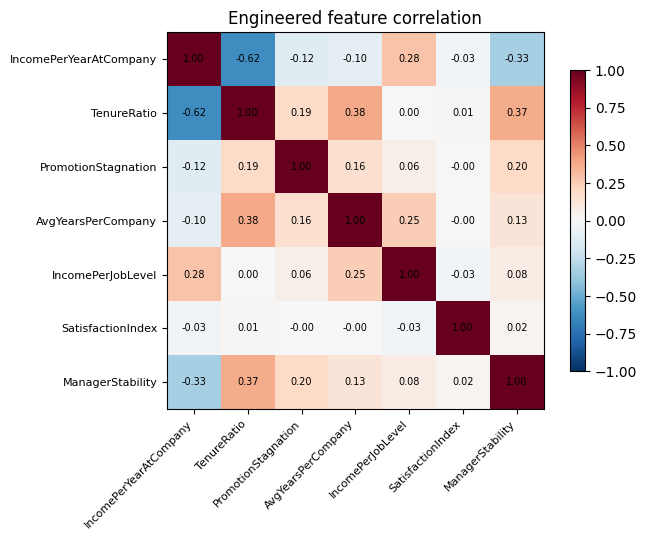

In [7]:
corr = X[ENGINEERED_COLUMNS].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(ENGINEERED_COLUMNS)))
ax.set_xticklabels(ENGINEERED_COLUMNS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(ENGINEERED_COLUMNS)))
ax.set_yticklabels(ENGINEERED_COLUMNS, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Engineered feature correlation")
fig.tight_layout()
plt.show()

`TenureRatio` and `ManagerStability` are related - both are built from tenure - but
not so tightly that one is redundant. Logistic regression is regularised by default,
so this level of collinearity is handled rather than fatal.

## Preprocessing

Numeric columns are median-imputed and scaled; categoricals are mode-imputed and
one-hot encoded with `handle_unknown="ignore"` so an unseen category at serving time
cannot crash a live prediction.

In [8]:
numeric, categorical = split_column_types(X)
print(f"{len(numeric)} numeric, {len(categorical)} categorical")
print("categorical:", categorical)

preprocessor = build_preprocessor(X)
transformed = preprocessor.fit_transform(X)
print(f"\nfinal design matrix: {transformed.shape}")
print(f"{X.shape[1]} columns -> {transformed.shape[1]} after one-hot encoding")

30 numeric, 7 categorical
categorical: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

final design matrix: (1470, 58)
37 columns -> 58 after one-hot encoding


## Persist the engineered table

Saved for inspection only. Training does not read this file - it applies the same
engineering inside the pipeline, which is what keeps training and serving identical.

In [9]:
out = X.copy()
out.insert(0, "EmployeeID", df["EmployeeID"])
out["AttritionFlag"] = y
out.to_csv(PROCESSED_FILES["features"], index=False)
print(f"written: {PROCESSED_FILES['features'].name}  {out.shape}")

written: attrition_features.csv  (1470, 39)
